### Heart Failure Prediction Dataset

#### This dataset contains 11 features that can be used to predict possible heart disease.

#### I will implement Tree Ensemble models (Random Forest and XGBoost models) and evaluate them.

#### Complete workflow is done by myself.

In [1]:
import pandas as pd
import numpy as np


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import os       

In [2]:
file_path = str(r"c:\Users\Admin\ML-concepts\datasets\heart.csv")
df = pd.read_csv(file_path)

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Attribute Information

    Age: age of the patient [years]
    Sex: sex of the patient [M: Male, F: Female]
    ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
    RestingBP: resting blood pressure [mm Hg]
    Cholesterol: serum cholesterol [mm/dl]
    FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
    RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
    MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
    ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
    Oldpeak: oldpeak = ST [Numeric value measured in depression]
    ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
    HeartDisease: output class [1: heart disease, 0: Normal]


### Target: HeartDisease -> Binary classification 

- 0 no disease

- 1 disease



### **EDA**

In [4]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
y.value_counts()

# balanced 

total = y.value_counts().sum()

df_y = pd.DataFrame(y.value_counts())
df_y['percentage'] = df_y['count'].apply(lambda row: row/total).round(2)
df_y

,count,percentage
HeartDisease,,
1,508,0.55
0,410,0.45


### Distribution of positive and negative class is fine, no need to stratify 

#### 1.1 Numerical features:

In [5]:
numeric = df.select_dtypes(include='number')
numeric.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [6]:
# Check if missing values exists (exclude target)
numeric = numeric.iloc[:,:-1]
(numeric==0).sum()

Age              0
RestingBP        1
Cholesterol    172
FastingBS      704
MaxHR            0
Oldpeak        368
dtype: int64

#### RestingBP: 1 missing value(impossible to have 0 for BP)

#### Cholesterol: 172 missing values (also impossible to have 0 cholesterol level)

#### FastingBS: 704 missing values (it's not technical missing value, but as the dataset explained, fasting bs < 120mg Glucose has 0 and >120mg has 1)


172 missing values for cholesterol should be corrected, and I may use Imputer method after observing additional key points

In [7]:
numeric['Cholesterol'].describe()

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64

### Scale of numerical feature is different, but since I will use Tree based models, there is no need to implement data scaling/normalization

### Numerical features descriptive statistics:

- 918 instances

In [8]:
numeric.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89
std,9.43,18.51,109.38,0.42,25.46,1.07
min,28.00,0.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,0.00,120.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60
75%,60.00,140.00,267.00,0.00,156.00,1.50
max,77.00,200.00,603.00,1.00,202.00,6.20


### Cholesterol feature has very high std, which implies heavy influence of outliers, and we may observe from upper data:

1) min = 0

2) max = 603

3) mean = 198

I expect that **cholesterol** has positive (right skew)

In [9]:
#Cleaning form zeros
cholesterol_no_zeros = numeric['Cholesterol']>0
cholesterol_no_zeros = numeric.loc[cholesterol_no_zeros,'Cholesterol']
(cholesterol_no_zeros==0).sum()

np.int64(0)

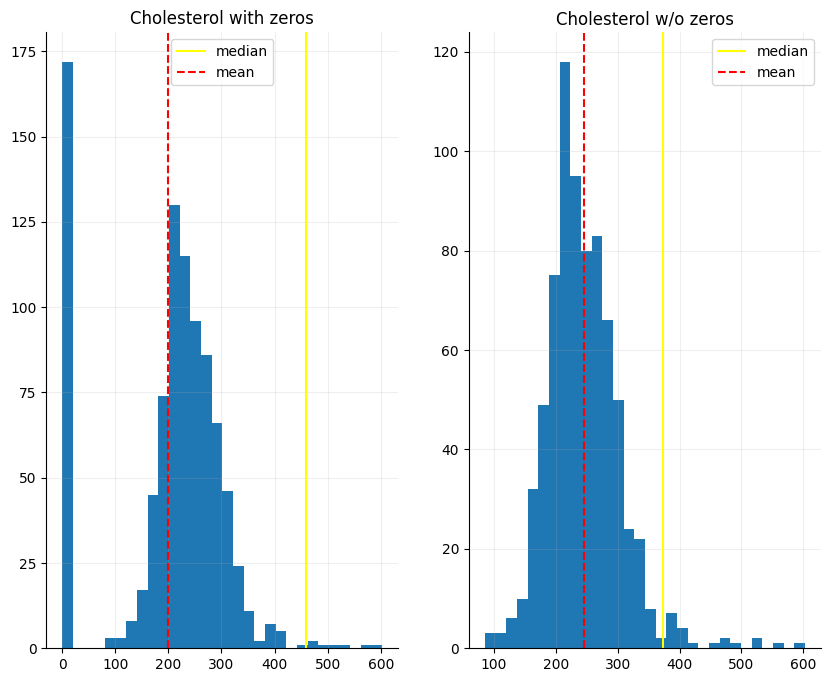

In [10]:
fig,ax = plt.subplots(1,2,figsize=(10,8))

ax[0].hist(df['Cholesterol'],bins=30)
ax[1].hist(cholesterol_no_zeros,bins=30)
n_clean = len(cholesterol_no_zeros)/2
mean_clean = cholesterol_no_zeros.mean()
ax[0].axvline(len(df)/2,label='median',color='yellow')
ax[0].axvline(df['Cholesterol'].mean(),label='mean',color='red',linestyle='--')

ax[1].axvline(n_clean,label='median',color='yellow')
ax[1].axvline(mean_clean,label='mean',color='red',linestyle='--')

ax[0].set_title("Cholesterol with zeros")
ax[1].set_title("Cholesterol w/o zeros")
for ax in ax.flatten():
    ax.spines[['top','right']].set_visible(False)
    ax.legend()
    ax.grid(alpha=0.2)

### Mean > Mode -> Right skew 

Since cholesterol has 171 missing value, and dataset has around 900 instances, it would be a loss to drop these rows where **cholesterol==0**. I consider imputation method, by using Median (initial thought) as a strategy for this dataset and observed distribution.

### 1.2 Categorical features

- I will use **Chi-square** test for 2 categorical variables in order to determine which variables are related

In [11]:

categorical =  df.select_dtypes(exclude='number')
categorical

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [147]:
z = pd.crosstab(categorical['RestingECG'],categorical['ST_Slope'])

In [13]:
from scipy.stats import chi2_contingency

In [148]:
z_new = z.reset_index()

In [164]:
z_new.columns

Index(['RestingECG', 'Down', 'Flat', 'Up', 'row_total'], dtype='object', name='ST_Slope')

In [150]:
cols = z_new.columns[1:]


In [151]:
z_new.loc['column_total'] = z_new[cols].sum(axis=0).round(2)

In [152]:
z_new

ST_Slope,RestingECG,Down,Flat,Up
0,LVH,17.0,97.0,74.0
1,Normal,31.0,266.0,255.0
2,ST,15.0,97.0,66.0
column_total,NaN,63.0,460.0,395.0


In [153]:
z_new['row_total'] = z_new[cols].sum(axis=1).round(2)

In [154]:
z_new

ST_Slope,RestingECG,Down,Flat,Up,row_total
0,LVH,17.0,97.0,74.0,188.0
1,Normal,31.0,266.0,255.0,552.0
2,ST,15.0,97.0,66.0,178.0
column_total,NaN,63.0,460.0,395.0,918.0


In [163]:
# Chi-Sq = sum ( O - E)^2/ E
# E = Row r x Col c / Total

N_total = z_new.iloc[-1,-1]
print(N_total)

lsit = list(z_new[cols].index)
lsit

918.0


[0, 1, 2, 'column_total']

### Inspection of each category and it's value counts:

In [ ]:
for col in categorical.columns:
    print(categorical[col].value_counts())

In [ ]:
chest_pain = pd.crosstab(categorical['ChestPainType'],df['HeartDisease'],margins=True)
chest_pain

#### ChestPain related to a target variable:

In [ ]:
chest_pain['percentage_heart_disase'] = chest_pain.apply(lambda row: row[1]/row['All'],axis=1)
chest_pain


#### Most common Asymptomatic Chest Pain -> highest HeartDisease incidence

In [ ]:
### Resting ECG / Target

rest_ecg = pd.crosstab(categorical['RestingECG'],df['HeartDisease'],normalize='index')
rest_ecg

# ST - indeed strongest contributor to positive class

In [ ]:
exercise_angina = pd.crosstab(categorical['ExerciseAngina'],df['HeartDisease'],normalize='index')
exercise_angina

### Exercise Angina -> good predictor variable

In [ ]:
st_slope = pd.crosstab(categorical['ST_Slope'],df['HeartDisease'])
st_slope['%_disease'] = st_slope.apply(lambda row: row[1]/row.sum(),axis=1).round(2)
st_slope

Flat ST_slope -> Good predictor variable

1) Sex - binary

2) ChestPainType - Unordered categorical variable (nominal) - candidate for OneHotEncoder

- ASY -> Asymptomatic **Patients in this category show no chest pain at all.**

- ATA -> Atypical Angina

- TA -> Typical Angina **Classic, heart-related chest pain**

- NAP -> Non-Angianl Pain **Chest discomfort that is not characteristic of heart disease (angina)**

3) RestingECG - Normal, LVH - Left Ventricular hyperthropy (worse patient health), ST - T inversion - Candidate for OHE of this feature (nominal feature)

4) ExerciseAngina - Binary

5) ST_SLope - flat , up , down - cnadidate for ordinal encoder

### 1.3 Correlation heatmap for numeric features /w Target feature (Normalized Variance [-1,1])

- Correlation is matrix of [ features x features ] that shows the interaction between each numeric feature

- Positive annotation -> increasing in one feature leads to increasing in another

- Negatve -> increasing in one leads to decreasing in another and vice versa

- If feature has negative correlation with a Target Feature, it does not mean that feature should be excluded. Correlation does not imply causality.

In [ ]:
numeric = df.select_dtypes(include='number')

sns.heatmap(numeric.corr().round(2),cmap='RdBu',annot=True)

### 1.4 EDA visualisation of the data ( Numerical features ):

1) **using correlation matrix to plot meaningful data correlation**


In [ ]:
corr_matrix = numeric.corr()
corr_matrix

In [ ]:
# FastingBS (numeric but not continous!)

numeric['FastingBS'].value_counts()

In [ ]:
abs(corr_matrix)>0.2

In [ ]:
clean_df_plot = numeric[numeric['Cholesterol']>0]
plt.scatter(clean_df_plot['Cholesterol'],clean_df_plot['MaxHR'],alpha=0.5)
plt.xlabel("Cholesterol")
plt.ylabel("Max HeartRate")
plt.title('Cholesterol VS MaxHR')
plt.show()

#### Plot implies that there is no evident relationship between increase in Cholesterol nad Maximum Heart Rate in the patient data

In [ ]:
sns.boxplot(data=numeric,x='FastingBS',y='MaxHR')

### Helper function to visualize boxplot of Target/Feature and it's distribution and how it affecets the patient state:

In [ ]:
# x axis will be HeartDisease -> target var
# y axis will be other features 
# boxplot 
selected_feature = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
def plot_boxplot(X,features):

    x1 = 'HeartDisease'
    n = len(features)
    print(features)
    fig,ax = plt.subplots(1,n,figsize=(10,6))

    for ax,feature in zip(ax.flatten(),features):
        sns.boxplot(data=X,x=x1,y=feature,ax=ax)
        plt.tight_layout()


In [ ]:
plot_boxplot(df,selected_feature)

### Summary of boxplot:

1) Age -> expected behaviour, showing that patients that are older have higher disease incidence, while having some outliers in the lower bound for positive class. From this data and dataset, we do not know anything about history of the patients, their lifestyle and maybe some co-morbidities present.

2) RestingBP -> Median for both classes is similar, while positive class has slighlty higher distribution spread, towrads the higher values of BP. We can not conclude that RestingBP affect the Heart Disease.

3) Cholesterol -> From the boxplot, we may conclude that Cholesterol is not such a good variable for discriminating between postiive and negative class. We need to take into consideration that Cholesterol variable has 170+ missing values, and like this, it's not informative.


4) Max Heart Rate -> We see that patients with no disease have higher maximum heart rate, which could be explained by the heart capacity to sustain exercise.  Lower max heart rate , and evidently lower mean value, indicate that this variable is informative in prediction task 

5) Oldpeak (Degree of ST segment depression measured on ECG during a **stress test** compared to a baseline at rest) 

- During an exercise, heart works harder to pump blood. If patient has some arterial plaque or calcification, they cannot supply enoguh bloodflow

- This shortage causes downward shift (depression) in the ECG ST segment

- downward shift >= 1.5-2 is implying significant indicator of coronar artery disease. 

In [ ]:
#resting bp , max hr and cholesterol
numeric_no_zero = numeric.loc[cholesterol_no_zeros,:]
numeric_no_zero['HeartDisease'] = df['HeartDisease']
sns.scatterplot(x=numeric_no_zero['RestingBP'],y=numeric_no_zero['MaxHR'],hue=numeric_no_zero['HeartDisease'])

### Cholesterol - has missing values. -> Candidate for imputation in the preprocessing 

- median imputation

In [ ]:
# Cholesterol
# in the original dataset:

df['Cholesterol'] = df['Cholesterol'].replace(0,np.nan)
df['Cholesterol'].isna().sum() # 172 sum values


### **1.4 EDA visualisation of the data ( Categorical features )**

In [ ]:
# categorical features from dataset

categorical = df.select_dtypes(exclude='number')
categorical

In [ ]:
categorical.groupby("RestingECG")['Sex'].describe()

In [ ]:
sns.countplot(data=categorical,x='RestingECG')

In [ ]:
categorical.groupby('ExerciseAngina')['RestingECG'].describe()

In [ ]:
sns.countplot(data=categorical,x='ExerciseAngina')

In [ ]:
angina_disease= pd.crosstab(categorical['ExerciseAngina'],df['HeartDisease']).reset_index()
angina_disease

In [ ]:
angina_disease.rename(mapper={0:'not_sick',1:'sick'},axis=1,inplace=True)
angina_disease

In [ ]:
angina_disease['%_disease'] =  (angina_disease['sick']/(angina_disease['sick']+angina_disease['not_sick'])).round(2)    

In [ ]:
ax2 = exercise_angina.plot(kind='bar',stacked=True)
for container in ax2.containers:
    ax2.bar_label(container,label_type='center',fmt='%.2f')

In [ ]:
sns.catplot(categorical,kind='bar',
            x='ST_Slope',y='ChestPainType',col='Sex',orient='h')

## **Feature Engineering**:

In [ ]:
chol = df['Cholesterol'].isna()==True
chol.sum()
z = chol.sum()/len(df)
z # 18% of feature has missing values

df['Cholesterol'].describe()
# mean imputation would be suitable

### Deciding on imputation method for **Cholesterol** feature

In [ ]:
sns.kdeplot(data=df.loc[df['Cholesterol']>0,:],x=df.loc[df['Cholesterol']>0,'Cholesterol'],hue='HeartDisease')

### Kernel density estimation plot - > Shows that the most occuring value of cholesterol is both for same groups around 220-250, while patients with heart disease (1) tend to have higher variablity in the cholesterol levels. 

y - value represents contribution of each group to cholesterol levels

x - cholesterol values

### Using **median** imputation may not be suitable because patients with a disease have a higher range of valeus for cholesterol and median from the general dataset is not representative.

#### Using grouping approach:

In [ ]:
df.loc[df['Cholesterol']>0,'Cholesterol'].groupby(df['HeartDisease']).describe()

In [ ]:
df.loc[df['Cholesterol']>0,'Cholesterol'].groupby(df['Sex']).describe()

In [ ]:
df[df['Cholesterol']>0].groupby(['Sex','HeartDisease'])['Cholesterol'].median()

##### By making 4 subgroups with patient Sex and HeartDisease , we observe that median are much different for each of the group. By simply imputing median via simple imputer, we would considerably infer the real median values for these groups. For example Females with positive class, have 275 median, and with imputation of Single median from the dataset, we would introduce high bias for that instance.

- **groupby().transform()**

In [ ]:
df['Cholesterol'] = df['Cholesterol'].replace(0,np.nan)
df.isna().sum()

In [ ]:
group_median = df.groupby(['Sex','HeartDisease'])['Cholesterol'].transform('median')

In [ ]:
df['Cholesterol'] = df['Cholesterol'].fillna(group_median)
# kde plot again

sns.kdeplot(data=df,x=df['Cholesterol'],hue='HeartDisease')

### **Preprocessing**:

- Splitting data into training/test groups

- ColumnTransformer 

- complete pipeline including column transformer + model

In [ ]:
X = df.iloc[:,:-1] # except target
y = df.iloc[:,-1] # target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f'X_Train :{X_train.shape}')
print(f"X_test:{X_test.shape}")


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [ ]:
for col in categorical.columns:
    print(col,categorical[col].unique())

**ST_SLOPE** -> Ordinal categories, have rank from mild to worse condition up -> flat -> down

In [ ]:
slope_size = categorical['ST_Slope'].unique()
slope_size

In [ ]:
preprocessing = ColumnTransformer(transformers=[
    #('imputer',SimpleImputer(strategy='mean'),['Cholesterol']), # first implementation -> corrected with grouping aproach above
    ('labelEncoder',OrdinalEncoder(),['Sex','ExerciseAngina']),
    ('OrdinalEncoder',OrdinalEncoder(categories=[slope_size]),['ST_Slope']),
    ('Ohe',OneHotEncoder(),['ChestPainType','RestingECG'])],
    remainder='passthrough')

## Preprocessing test on SingleTree

In [ ]:
mini_pipe = make_pipeline(
    preprocessing,
    DecisionTreeClassifier()
)

mini_pipe.fit(X_train,y_train)

In [ ]:
from sklearn.metrics import precision_score,recall_score,classification_report
y_pred = mini_pipe.predict(X_test)
report = classification_report(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
print(f"Baseline precision: {precision}")
print(f"Baseline recall: {recall}\n")
print(report)

## **Modeling** - Baseline with crossvalidation (k=5)

### Models: 

- Single Classification Tree (baseline)

- RandomForest

- XGCBoost

### Scores:

- f1

- precision

- accuracy

- roc_auc

- precision_recall

In [ ]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score,precision_recall_curve,roc_auc_score,roc_curve,f1_score

In [ ]:
models = {
    'Tree':DecisionTreeClassifier(random_state=42),
    'Forest':RandomForestClassifier(random_state=42),
    'Xboost':XGBClassifier(random_state=42)
}

In [ ]:
# pipeline (preprocessing + model) 

complete_pipeline = {}

for name,model in models.items():
    make_pipe = make_pipeline(
        preprocessing,
        model
    )
    complete_pipeline[name] = make_pipe

In [ ]:
score_list = ['f1','accuracy','precision','recall','roc_auc']

def get_scores(X,y,pipe,scores):
    score_storage = {}


    for name,estimator in pipe.items():
        score_storage[name] = {}

        for score in scores:
            result = cross_val_score(estimator,X,y,scoring=score,cv=5)
            score_storage[name][score] = result.mean().round(2)
    return score_storage


In [ ]:
baseline_score = get_scores(X_train,y_train,complete_pipeline,score_list)

In [ ]:
baseline_score_pd = pd.DataFrame(baseline_score)
baseline_score_pd.T.sort_values(by='f1',ascending=False)

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

y_preds = {}
y_probas = {}

for name,model in complete_pipeline.items():
    y_hat = cross_val_predict(model,X_train,y_train,cv=5,method='predict')
    y_preds[name]= y_hat
    probas = cross_val_predict(model,X_train,y_train,cv=5,method='predict_proba')[:,1]
    y_probas[name] = probas

In [ ]:
collect = {}
for name,preds in y_preds.items():
    cm = confusion_matrix(y_train,preds,labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    collect[name] = tn,fp,fn,tp
    z = ConfusionMatrixDisplay(cm,display_labels=['No Disease','Disease'])
    z.plot()
    z.ax_.set_title(f'{name}-model')

In [ ]:
values_df = pd.DataFrame(collect)

In [ ]:
values_df.rename(mapper={0:'tn',1:'fp',2:'fn',3:'tp'},inplace=True)

In [ ]:
values_df.T.sort_values(by='tp',ascending=False)

### XGBClassifier baseline model shows best performance among 3 models, with highest number of True Negatives and True positives. Also lowest number of False Positives samples

- In this data science problem, it is important to have more true positives with less false negatives.

- we want to capture all positive samples and eliminate most of false negatives. We dont want to say to a patient that he is not sick , and he is actually sick (Type 2 eror)

In [ ]:
values_df

In [ ]:

baseline_score_pd

In [ ]:
# ROC auc and PR curve
def plot_curves(complete_pipe,y,y_proba):

    storage = {}
    positive_class = sum(y_test==1)/len(y_test)

    fig,ax = plt.subplots(1,2,figsize=(10,8))
    for name,model in complete_pipe.items():
        storage[name] = {}
        precision,recall,threshold_pr = precision_recall_curve(y,y_proba[name])
        fpr,tpr,threshold_roc = roc_curve(y,y_proba[name])
        storage[name]['pr'] = precision
        storage[name]['rec'] = recall
        storage[name]['fpr'] = fpr
        storage[name]['tpr'] = tpr
    
    for i,(name,model) in enumerate(complete_pipe.items()):
        ax[0].plot(storage[name]['rec'],storage[name]['pr'],label=f"{name}")
        ax[1].plot(storage[name]['fpr'],storage[name]['tpr'],label=f"{name}")
    
    # Dummy classifier
    ax[0].axhline(positive_class,linestyle='-',color='red',label="Dummy:0.58 accuracy positive class")
    ax[1].plot([0,1],[0,1],color='red',linestyle='--',label='Dummy:AUC(0.5)')
    
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[1].set_xlabel("false positive rate")
    ax[1].set_ylabel("true positive rate")
    for i in range(len(ax)):
        ax[i].grid(alpha=0.2)
        ax[i].legend()
        ax[i].spines[['top','right']].set_visible(False)

z = plot_curves(complete_pipeline,y_train,y_probas)

### Precision Recall curve:

- Trade off between precision and recall. At highest values of precision, recall value is low. At low values of recal , precision suddenly drops and then stabilizes at high value. We aim to find a dot that points at highest value of recall with the possible highest value of precision. Since my goal is to detect most True Classes and less False negatives

### ROC curve:

It shows how well model can distinguish between positive and negative class. Red line represets the DummyClassifier which represents random class assign.


### We may see from the graph that RandomForest keeps highest precision for the highest values of recall

### Hyperparameters:

DT Hyperparameters are external configuration settings used to control the structure, growth, and complexity of a decision tree model. 

Because unconstrained decision trees naturally grow until they completely memorize the training data, tuning these settings is the primary defense 

against __overfitting__.



In [ ]:
parameters = {
    'Tree':{'decisiontreeclassifier__max_depth':[1,2,3,4,6,8,16],'decisiontreeclassifier__min_samples_split':[2,4,8,16,32,64,128]},
    'Forest':{'randomforestclassifier__n_estimators':[10,50,100,500],'randomforestclassifier__min_samples_split':[2,4,8,16,32,64,128],'randomforestclassifier__max_depth':[2, 4, 8, 16]},
    'Xboost':{'xgbclassifier__n_estimators':[500],'xgbclassifier__learning_rate':[0.05,0.1,0.2,0.4],'xgbclassifier__verbosity':[1],'xgbclassifier__subsample':[0.8,1]}
            
}

#### All 3 models defined in the upper cell are tree based, thus they can use initial column_transformer ( same transformations are applied to same columns)

- preprocessing

In [ ]:
preprocessing

## GridSearchCV

- Class used for exhaustive search for parameters predefined 

- GridSearchCV try all possible combination of parameters:

example: 

max_depth: [2,4,7]
min_samples_leaf: [2,4,8]

**9 times the model is fit**

**While this can be computationally expensive, it's the best method to obtain best parameters in small-medium param. grid size.**

### Alternative: RandomizedSearchCV -> Picks random parameters to train the model **best used for small grids and fast execution**
---
**GridSearchCV**

- estimator

- param_grid: list or list of dicts with parameters 

- scoring

- n_jobs: -1 all cores utilization

- refit: **default: True** -> refits the estimator with best found parameters on the whole dataset

- cv: CV splitting strategy, specify k (number of folds used for test , k - 1 for training)

In [ ]:
def grid_search(X,y,pipe,params,cv):

    grid_output = {}

    for name,model in pipe.items():
        grid_output[name] = {}
        estimator = model
        pars = params[name]
        g = GridSearchCV(estimator,pars,cv=cv,verbose=1,n_jobs=-1,scoring='f1',refit=True)
        g.fit(X,y)
        grid_output[name]['best_model'] = g.best_estimator_
        grid_output[name]['best_scores'] =g.best_score_
        grid_output[name]['cv_results'] = g.cv_results_
        grid_output[name]['best_params'] = g.best_params_
    return grid_output

tuning_output = grid_search(X_train,y_train,complete_pipeline,parameters,5)

In [ ]:
best_models = {}
for name,values in tuning_output.items():
    print(values)
    best_models[name] = values['best_model']

In [ ]:
optimized_scores_pd = {}
probas_2 = {}
for name,model in best_models.items():
    optimized_scores_pd[name] = {}
    probas_2[name] = {}
    y_preds = cross_val_predict(model,X_train,y_train,cv=5,method='predict')
    y_probas = cross_val_predict(model,X_train,y_train,cv=5,method='predict_proba')[:,1]
    probas_2[name] = y_probas
    for score in score_list:
        scores = cross_val_score(model,X_train,y_train,cv=5,scoring=score)
        optimized_scores_pd[name][score] = scores.mean()

    

In [ ]:
optimized_scores_pd = pd.DataFrame(optimized_scores_pd)

In [ ]:
optimized_scores_pd.sort_values(by='f1',ascending=False,axis=1)


### PR and ROC curve with optimized hyperparameters:

In [ ]:
p = plot_curves(best_models,y_train,probas_2)

In [ ]:
optimized_scores_pd.sort_values(by='f1', ascending=False,axis=1).round(2)

In [ ]:
baseline_score_pd.sort_values(by='f1',ascending=False,axis=1)

In [ ]:
data_difference = baseline_score_pd.compare(optimized_scores_pd)

In [ ]:
data_difference.rename(mapper={'self':'baseline','other':'tuned_parameters'},axis=1,inplace=True)

In [ ]:
data_difference

In [ ]:
# Visualization of this multiindex col. dataframe
# 1) reset index
data_difference = data_difference.reset_index(col_level=1)

In [ ]:
data_difference.rename(mapper={'index':'metrics'},axis=1,inplace=True)

In [ ]:
data_difference.columns = data_difference.columns.map(mapper='_'.join)

In [ ]:
data_difference = data_difference.round(2)
data_difference

In [ ]:
var_cols = [c for c in data_difference.columns if c.endswith('_baseline') or c.endswith('_parameters')]
print(var_cols)
pd_melt = pd.melt(data_difference,id_vars=['_metrics'],value_vars=var_cols,var_name='model')

In [ ]:
pd_melt.sort_values(by='value',ascending=False)

In [ ]:
recall_mask = pd_melt['_metrics'] == 'recall'
f1_mask = pd_melt['_metrics'] =='f1'
max_recall = pd_melt.loc[recall_mask,'value'].max()
max_f1= pd_melt.loc[f1_mask,'value'].max()
print(f"Max recall {max_recall}")
print(f"max f1: {max_f1}")

In [ ]:
sns.catplot(data=pd_melt,x='_metrics',y='value',hue='model',kind='bar')
plt.scatter(x=3,y=max_recall,s=150,marker='x',color='black')
plt.scatter(x=0,y=max_f1,s=100,marker='x',color='black')

In [ ]:
best_models.values()

In [ ]:
tuning_output['Tree'].keys()

### Score on validation fold on X_train set:

- scoring metric has been set to f1

- ['mean_test_score'] gives score on validation fold during CV.

In [ ]:
tuning_output['Forest']['cv_results'].keys() # scoring parameter is set to 'f1' 
#tuning_output['Forest']['cv_results']['std_test_score'].mean()

Dakle ono sto je bitno jeste da prikupim ceo output iz grid_output-a u recnik. 

Svaki model mora da ima best_estimator_, best_scores_, best_params_ i cv_results_

1) __best_estimator___ predstavlja model sa najboljom kombinacijom parametara -> daje najveci mean_test_score koji je odredjen metrikom u Gridu **scoring=f1**

2) __best_scores___ predstavlja najbolji mean cross-validovani skroz dobijen iz validation-folda tokom treniranja-> ovo je mean tih skorova iz svakog fold-a

3) __best_params___ predstavlja najbolje parametre koji imaju najveci mean test skor dobijen cross validacijom na validacionim foldovima

4) __cv_results___ dict sa svim metrikama

In [ ]:
# Select FOREST

cv_df = pd.DataFrame(tuning_output['Forest']['cv_results'])
print(cv_df.columns)
cv_df[['mean_test_score','std_test_score','rank_test_score','params']].sort_values(by='mean_test_score',ascending=False)

In [ ]:
cv_df.loc[cv_df['rank_test_score']==1,['mean_test_score','std_test_score','rank_test_score','params']]

In [ ]:
# mean_test_score visok
# std nizak
# best 1% - highest mean test score

best_mean_score = cv_df['mean_test_score'].max()
best_mean_score
candidate = cv_df.loc[cv_df['mean_test_score']>=best_mean_score-0.01,['mean_test_score','std_test_score','rank_test_score','params']].sort_values(by='std_test_score',ascending=True)
candidate

### mean_test_score -> sum of 'f1' score on validation fold in CrossValidation 

### std_test_score -> how each fold score vary. 

## **rank_test_score** -> most stable model **rank_test_score** = 9

Nakon Grid Search analize ne gledam samo najbolji mean_test_score koji predstavlja avg. f1 skora po validation foldovima CrossValidacije, vec gledam i varijaciju izmedju foldova. Manja varijacija izmedju test foldova predstavlja stabilniji model. U ovom slucaju, model sa kombinacijom parametara koja pripada rank_test_score = 9 predstavlja ujedno i najveci mean_test_score ali i najmanji std_test_score i biram ove parametre.

### Jednostavnom proverom parametara best_estimator_ iz Grid-a, vidimo da su hiperparametri bas ti koje smo i ovde izabrali rucno

In [ ]:
best_models['Forest'].get_params

In [ ]:
selected_params_final = candidate.loc[candidate['rank_test_score']==9,'params']

In [ ]:
selected_param_final_list = selected_params_final.to_list()[0]
selected_param_final_list

In [ ]:
prefix = 'randomforestclassifier__'
new_clean = {}

for name,value in selected_param_final_list.items():
    if name.startswith(prefix):
        new_clean[name[len(prefix):]] = value



In [ ]:
new_clean

In [ ]:
rf_final = RandomForestClassifier(**new_clean,random_state=42)
rf_final

#### Test set evaluation


In [ ]:
#RF_final.fit(X_train,y_train)
final_pipe = {}
rf_final_pipe = make_pipeline(
    preprocessing,
    rf_final
)
rf_final_pipe

final_pipe['Forest'] = rf_final_pipe

In [ ]:
rf_final_pipe.fit(X_train,y_train)

In [ ]:
# Predictions on test set
y_pred_proba_final = {}
y_pred = rf_final_pipe.predict(X_test)
y_pred_proba = rf_final_pipe.predict_proba(X_test)[:,1]

y_pred_proba_final['Forest'] = y_pred_proba

In [ ]:
print(score_list)
final_score_list = [f1_score,accuracy_score,precision_score,recall_score]
final_scores = {}

for score in final_score_list:
    final_scores[score.__name__] = score(y_test,y_pred)


final_scores['roc_auc_score'] = roc_auc_score(y_test,y_pred_proba)

In [ ]:
baseline_score_pd

In [ ]:

final_scores_pd = pd.DataFrame({'Forest':final_scores})
final_scores_pd

In [ ]:
final_scores_pd.reset_index(inplace=True)

In [ ]:
final_scores_pd

In [ ]:
optimized_scores_pd = optimized_scores_pd.reset_index()

In [ ]:
optimized_scores_pd['index'] = optimized_scores_pd['index'].apply(lambda x: x+'_score')

In [ ]:
optimized_scores_pd

In [ ]:
optimized_scores_pd = optimized_scores_pd[['index','Forest']]


In [ ]:
optimized_scores_pd

In [ ]:
compared_final = optimized_scores_pd.compare(final_scores_pd,result_names=('hyperparam_optimized','final_model'),keep_equal=True)

In [ ]:
compared_final['metrics'] = optimized_scores_pd['index']

In [ ]:
compared_final

In [ ]:
cm = ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
cm.ax_.set_title('Final Model - Test set')

In [ ]:
precision,recall,threshold = precision_recall_curve(y_test,y_pred_proba)
plot_curves(final_pipe,y_test,y_pred_proba_final)

In [ ]:
# tuning threshold (medical context)

new_threshold = 0.35

y_pred_threshold = (y_pred_proba>0.35).astype(int)
y_pred_proba_final_threshold = {}
y_pred_proba_final_threshold['Forest'] = y_pred_threshold
from sklearn.metrics import PrecisionRecallDisplay
precision,recall,th = precision_recall_curve(y_test,y_pred_threshold)
pd = PrecisionRecallDisplay(precision,recall)
pd.plot()